In [39]:
import glob

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from fairchem.core.datasets import AseDBDataset
from sklearn.preprocessing import StandardScaler

# Working with the Dataset

Below, we will load the dataset as a pandas DataFrame. We will first define a helper function for loading the data files: 

In [4]:
def convert_aselmdb_df(file_path):
    '''Convers the contents of a single aselmdb file to a pandas df.'''
    dataset = AseDBDataset({"src": file_path})
    rows = list(map(lambda idx: dataset.get_atoms(idx).info, range(len(dataset))))
    return pd.DataFrame(rows) 

In [5]:
# get all files in directory with the .aselmdb extension 
files = glob.glob('../data/*.aselmdb')

# change this value depending on how many mols you want to load; for EDA, sufficient to use just a subset 
# 40 -> approx 2M molecules (half)
max = 40 

df_list = [convert_aselmdb_df(f) for f in files[:max]]
df = pd.concat(df_list, ignore_index=True)

In [6]:
# view info 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1993378 entries, 0 to 1993377
Data columns (total 25 columns):
 #   Column                Dtype  
---  ------                -----  
 0   source                str    
 1   reference_source      str    
 2   data_id               str    
 3   charge                int64  
 4   spin                  int64  
 5   num_atoms             int64  
 6   num_electrons         int64  
 7   num_ecp_electrons     int64  
 8   n_scf_steps           int64  
 9   n_basis               int64  
 10  unrestricted          bool   
 11  nl_energy             float64
 12  integrated_densities  object 
 13  homo_energy           object 
 14  homo_lumo_gap         object 
 15  s_squared             float64
 16  s_squared_dev         float64
 17  warnings              object 
 18  mulliken_charges      object 
 19  lowdin_charges        object 
 20  composition           str    
 21  nbo_charges           object 
 22  mulliken_spins        object 
 23  lowdin_spins      

In [7]:
# not all data cols are useful (administrative details); we will drop them
cols_to_drop = ['source', 'warnings', 'reference_source', 'unrestricted']

new_df = df.drop(columns = cols_to_drop)
new_df.head() 

,data_id,charge,spin,num_atoms,num_electrons,num_ecp_electrons,n_scf_steps,n_basis,nl_energy,integrated_densities,...,homo_lumo_gap,s_squared,s_squared_dev,mulliken_charges,lowdin_charges,composition,nbo_charges,mulliken_spins,lowdin_spins,nbo_spins
0,biomolecules,-1,1,126,500,0,14,3024,49.781523,"[250.000105889668, 250.000105889668, 500.00021...",...,[7.276215777371704],0.0,0.0,"[-1.068958, 0.757119, -0.698328, 0.316796, 0.3...","[-0.007139, -0.483788, -0.036406, 0.078895, 0....",C43H60N11O11S1,NaN,NaN,NaN,NaN
1,biomolecules,0,1,17,56,0,13,352,5.857359,"[28.000005984737, 28.000005984737, 56.00001196...",...,[10.561827371497902],0.0,0.0,"[-1.354684, 0.408884, -0.68557, 0.432601, -0.4...","[-0.061441, -0.458218, -0.09764, -0.549318, 0....",C4H10N2O1,"[-0.63755, -0.03216, -0.50881, 0.68084, -0.834...",NaN,NaN,NaN
2,trans1x,0,1,11,46,0,16,273,4.894729,"[23.000002352563, 23.000002352888, 46.00000470...",...,"[10.672686558161175, 10.672686558161175]",0.0,0.0,"[-0.643859, 0.007795, -0.387112, -0.337293, 0....","[0.056604, -0.27825, -0.065501, 0.051042, -0.4...",C3H5N1O2,"[-0.80581, -0.19081, -0.07756, -0.48587, 0.768...","[-1.3e-05, 7e-06, 2e-06, 2e-06, -9e-06, 8e-06,...","[2e-06, -0.0, 1e-06, 0.0, -6e-06, 5e-06, -0.0,...","[0.0, 0.0, 0.0, 0.0, -1e-05, 1e-05, 0.0, 0.0, ..."
3,elytes,0,1,77,316,0,15,1814,33.376078,"[158.000009556135, 158.000009556135, 316.00001...",...,[8.120748354023966],0.0,0.0,"[-0.76121, 0.129727, -0.624985, -0.183971, 0.4...","[-0.267821, 0.898876, -0.266893, -0.256407, -0...",C20H39N2O14P1S1,NaN,NaN,NaN,NaN
4,biomolecules,0,1,2,2,0,8,18,0.239242,"[0.999999996219, 0.999999996219, 1.999999992439]",...,[14.089266553222652],0.0,0.0,"[-0.0, 0.0]","[-0.0, 0.0]",H2,NaN,NaN,NaN,NaN


In [8]:
new_df.head()

,data_id,charge,spin,num_atoms,num_electrons,num_ecp_electrons,n_scf_steps,n_basis,nl_energy,integrated_densities,...,homo_lumo_gap,s_squared,s_squared_dev,mulliken_charges,lowdin_charges,composition,nbo_charges,mulliken_spins,lowdin_spins,nbo_spins
0,biomolecules,-1,1,126,500,0,14,3024,49.781523,"[250.000105889668, 250.000105889668, 500.00021...",...,[7.276215777371704],0.0,0.0,"[-1.068958, 0.757119, -0.698328, 0.316796, 0.3...","[-0.007139, -0.483788, -0.036406, 0.078895, 0....",C43H60N11O11S1,NaN,NaN,NaN,NaN
1,biomolecules,0,1,17,56,0,13,352,5.857359,"[28.000005984737, 28.000005984737, 56.00001196...",...,[10.561827371497902],0.0,0.0,"[-1.354684, 0.408884, -0.68557, 0.432601, -0.4...","[-0.061441, -0.458218, -0.09764, -0.549318, 0....",C4H10N2O1,"[-0.63755, -0.03216, -0.50881, 0.68084, -0.834...",NaN,NaN,NaN
2,trans1x,0,1,11,46,0,16,273,4.894729,"[23.000002352563, 23.000002352888, 46.00000470...",...,"[10.672686558161175, 10.672686558161175]",0.0,0.0,"[-0.643859, 0.007795, -0.387112, -0.337293, 0....","[0.056604, -0.27825, -0.065501, 0.051042, -0.4...",C3H5N1O2,"[-0.80581, -0.19081, -0.07756, -0.48587, 0.768...","[-1.3e-05, 7e-06, 2e-06, 2e-06, -9e-06, 8e-06,...","[2e-06, -0.0, 1e-06, 0.0, -6e-06, 5e-06, -0.0,...","[0.0, 0.0, 0.0, 0.0, -1e-05, 1e-05, 0.0, 0.0, ..."
3,elytes,0,1,77,316,0,15,1814,33.376078,"[158.000009556135, 158.000009556135, 316.00001...",...,[8.120748354023966],0.0,0.0,"[-0.76121, 0.129727, -0.624985, -0.183971, 0.4...","[-0.267821, 0.898876, -0.266893, -0.256407, -0...",C20H39N2O14P1S1,NaN,NaN,NaN,NaN
4,biomolecules,0,1,2,2,0,8,18,0.239242,"[0.999999996219, 0.999999996219, 1.999999992439]",...,[14.089266553222652],0.0,0.0,"[-0.0, 0.0]","[-0.0, 0.0]",H2,NaN,NaN,NaN,NaN


In [9]:
data_ids = new_df['data_id']
print(f"Num unique molecule types: {data_ids.nunique()}")
print(f"Unique molecules = {data_ids.unique()}")

df_encoded = pd.get_dummies(new_df, columns = ['data_id'], dtype=int)
df_encoded

Num unique molecule types: 10
Unique molecules = <StringArray>
[   'biomolecules',         'trans1x',          'elytes', 'metal_complexes',
           'ani2x',             'rgd',      'reactivity',      'geom_orca6',
           'spice',   'orbnet_denali']
Length: 10, dtype: str


,charge,spin,num_atoms,num_electrons,num_ecp_electrons,n_scf_steps,n_basis,nl_energy,integrated_densities,homo_energy,...,data_id_ani2x,data_id_biomolecules,data_id_elytes,data_id_geom_orca6,data_id_metal_complexes,data_id_orbnet_denali,data_id_reactivity,data_id_rgd,data_id_spice,data_id_trans1x
0,-1,1,126,500,0,14,3024,49.781523,"[250.000105889668, 250.000105889668, 500.00021...",[-5.460345565193629],...,0,1,0,0,0,0,0,0,0,0
1,0,1,17,56,0,13,352,5.857359,"[28.000005984737, 28.000005984737, 56.00001196...",[-9.656477347081179],...,0,1,0,0,0,0,0,0,0,0
2,0,1,11,46,0,16,273,4.894729,"[23.000002352563, 23.000002352888, 46.00000470...","[-9.820453159264018, -9.820453159264018]",...,0,0,0,0,0,0,0,0,0,1
3,0,1,77,316,0,15,1814,33.376078,"[158.000009556135, 158.000009556135, 316.00001...",[-8.523694558272796],...,0,0,1,0,0,0,0,0,0,0
4,0,1,2,2,0,8,18,0.239242,"[0.999999996219, 0.999999996219, 1.999999992439]",[-12.723799202519903],...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993373,-4,1,35,154,28,40,793,16.499552,"[76.999339557203, 76.999339557203, 153.9986791...",[4.773557393324624],...,0,0,1,0,0,0,0,0,0,0
1993374,0,1,12,76,0,21,353,8.055654,"[38.000001945783, 38.000001946681, 76.00000389...","[-8.47705424262703, -8.477135876785104]",...,0,0,0,0,0,0,1,0,0,0
1993375,2,3,125,548,60,24,3097,53.959431,"[274.999920751789, 272.999898616861, 547.99981...","[-12.64657328898275, -12.68651960366652]",...,0,0,0,0,1,0,0,0,0,0
1993376,0,1,13,156,0,22,466,17.298137,"[77.99994839287, 77.999948393883, 155.99989678...","[-8.987975226620549, -8.9879208038485]",...,0,0,0,0,0,0,1,0,0,0


In [18]:
num_df = df_encoded.select_dtypes(include=['number'])
num_df.head()

,charge,spin,num_atoms,num_electrons,num_ecp_electrons,n_scf_steps,n_basis,nl_energy,s_squared,s_squared_dev,data_id_ani2x,data_id_biomolecules,data_id_elytes,data_id_geom_orca6,data_id_metal_complexes,data_id_orbnet_denali,data_id_reactivity,data_id_rgd,data_id_spice,data_id_trans1x
0,-1,1,126,500,0,14,3024,49.781523,0.0,0.0,0,1,0,0,0,0,0,0,0,0
1,0,1,17,56,0,13,352,5.857359,0.0,0.0,0,1,0,0,0,0,0,0,0,0
2,0,1,11,46,0,16,273,4.894729,0.0,0.0,0,0,0,0,0,0,0,0,0,1
3,0,1,77,316,0,15,1814,33.376078,0.0,0.0,0,0,1,0,0,0,0,0,0,0
4,0,1,2,2,0,8,18,0.239242,0.0,0.0,0,1,0,0,0,0,0,0,0,0


/Users/karaha/miniconda3/envs/fairchem/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/karaha/miniconda3/envs/fairchem/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/karaha/miniconda3/envs/fairchem/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/karaha/miniconda3/envs/fairchem/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/karaha/miniconda3/envs/fairchem/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/karaha/miniconda3/envs/fairchem/lib/python3.11/site-packages/scipy/_lib/_util.py:

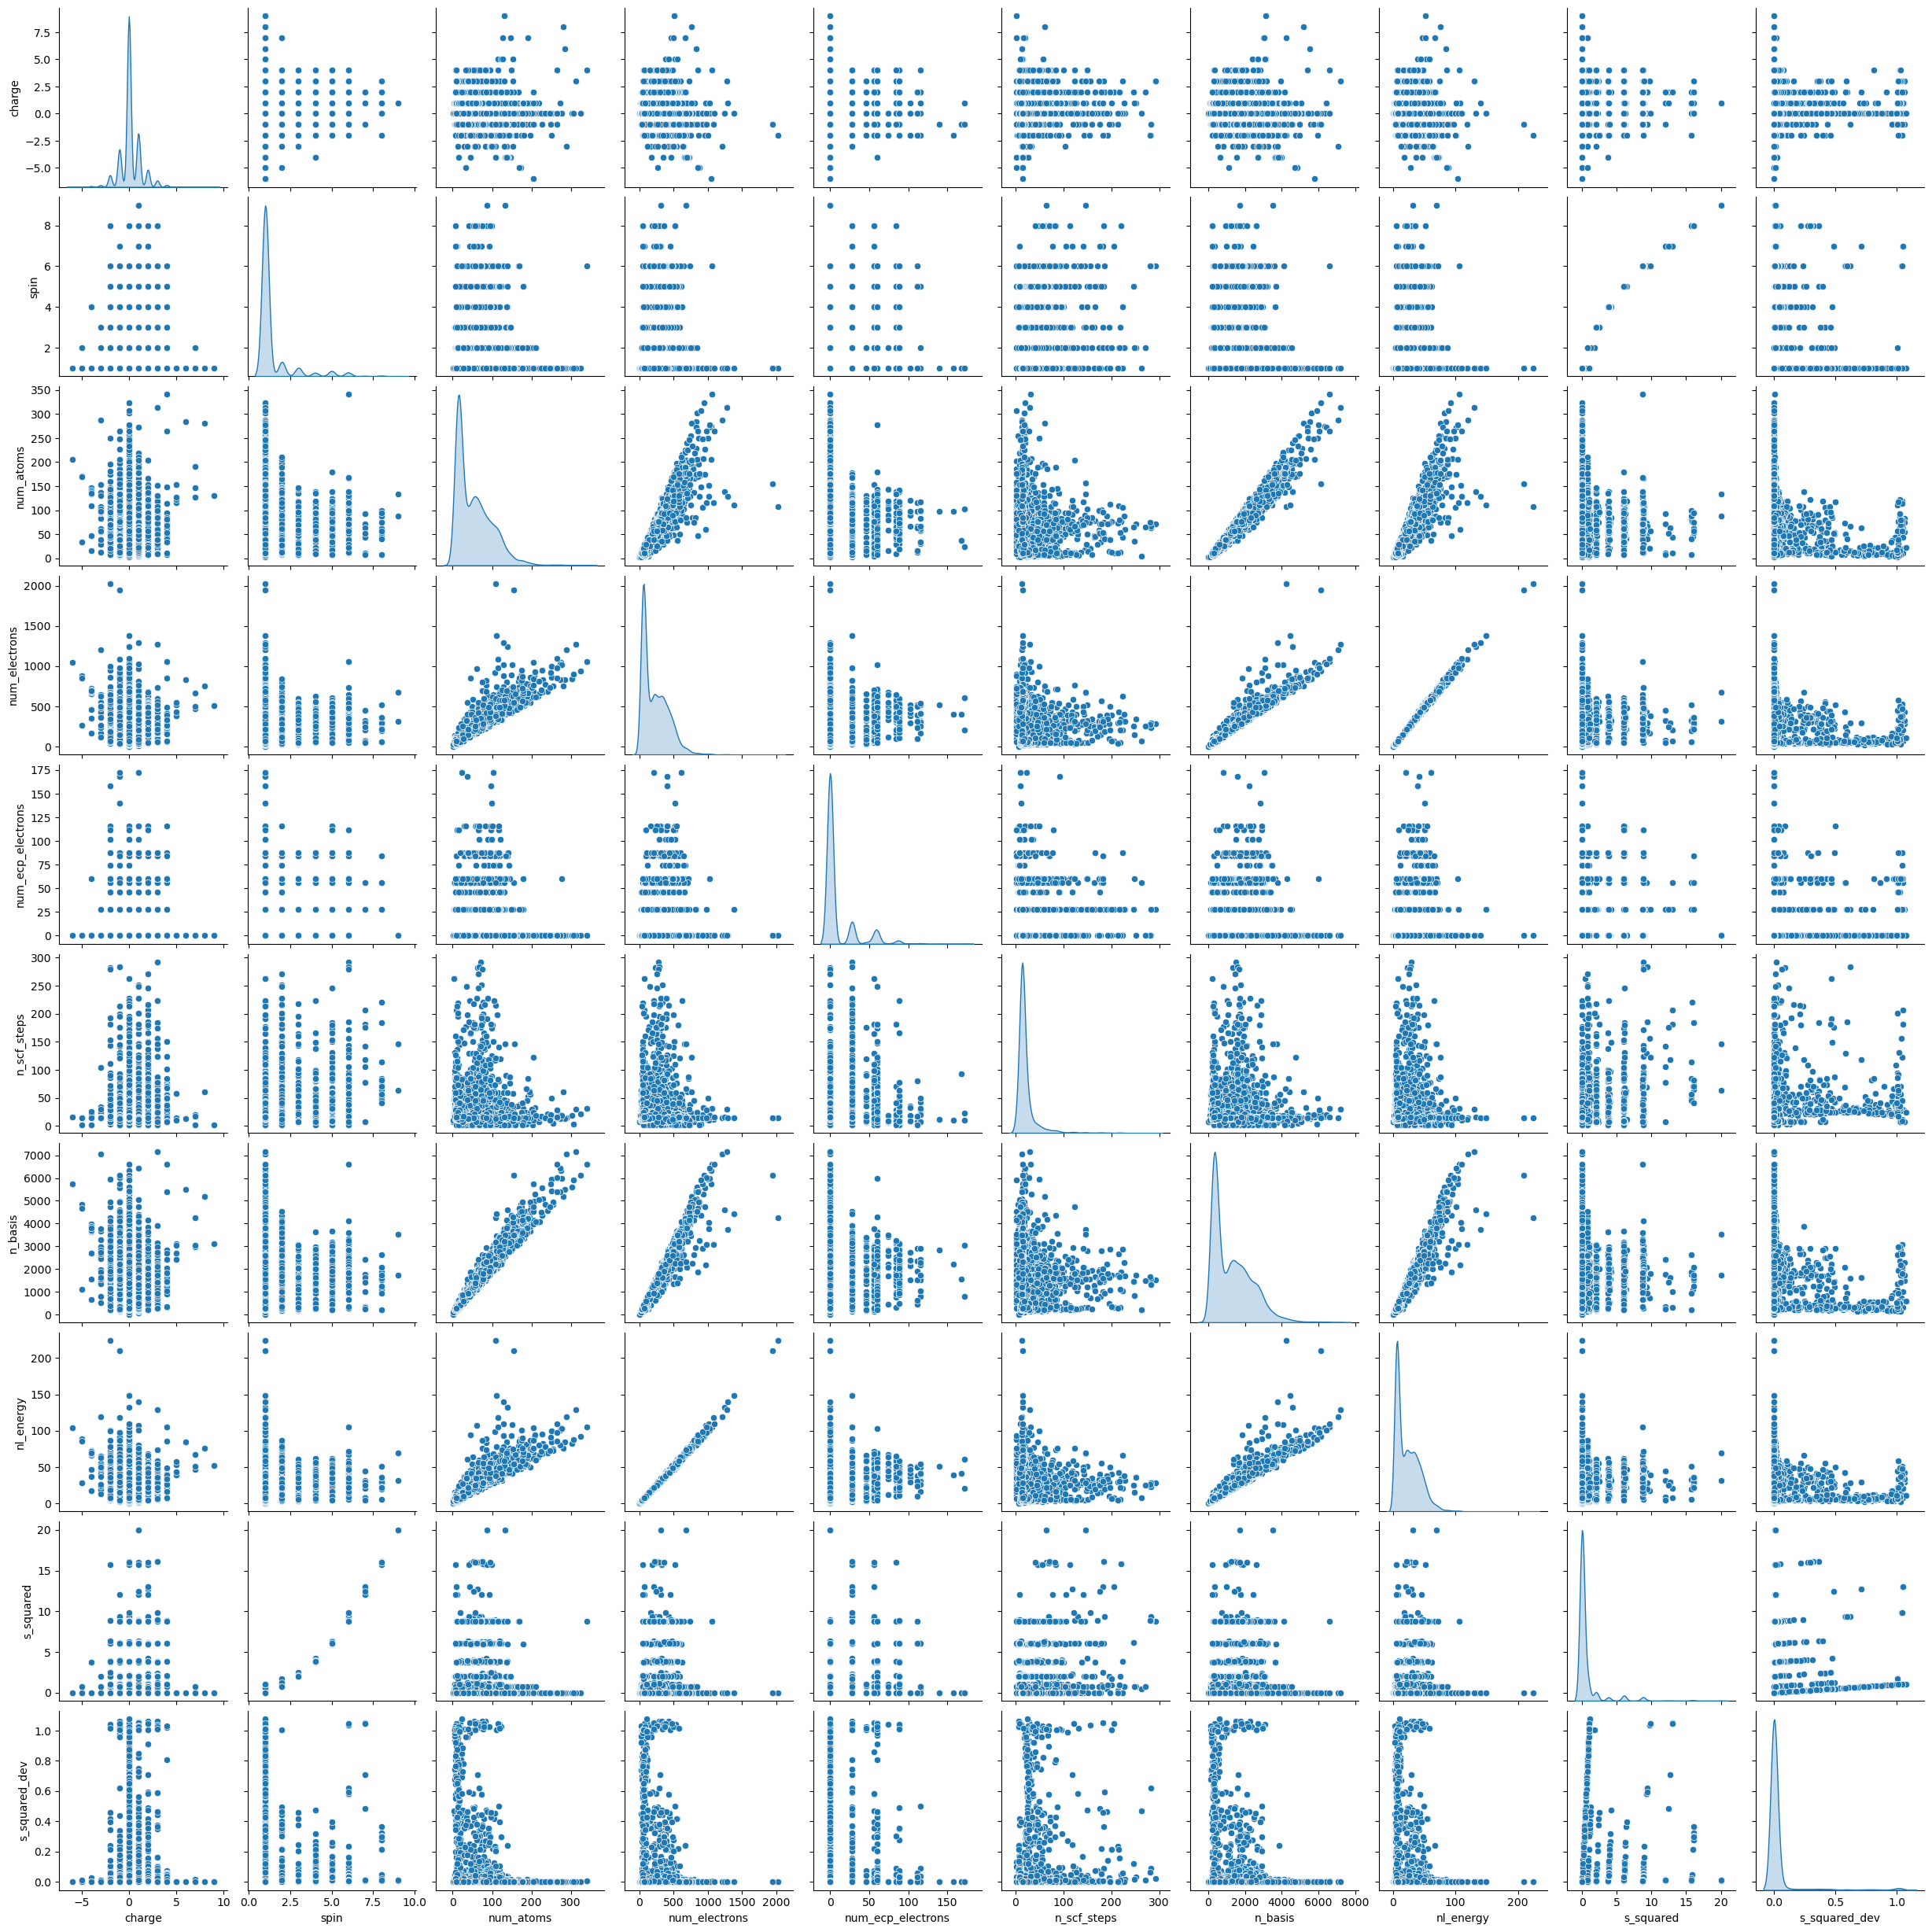

In [23]:
# numerical data types without encoded ids 
no_ids_df = new_df.select_dtypes(include = ['number'])

sns.pairplot(no_ids_df.iloc[:5000], diag_kind='kde') # use subset for pairplot, else crashes 

plt.title("KDE Pairplot")
plt.show()

In [26]:
# scale data before analysis 
# chose standard scaler based on pairplot results above
# might explroe other scaling methods?
scalar = StandardScaler()

x_scaled = scalar.fit_transform(num_df)
x_scaled = pd.DataFrame(x_scaled, columns=num_df.columns)

Text(0.5, 1.0, 'Correlation Heatmap')

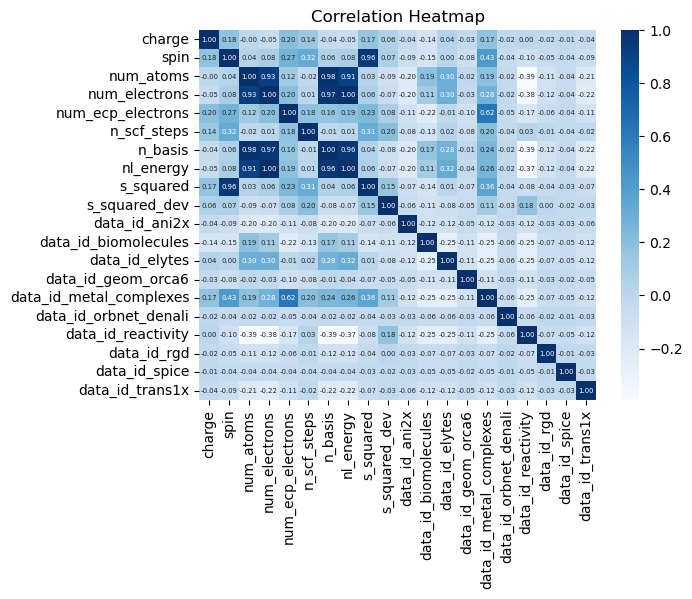

In [27]:
sns.heatmap(x_scaled.corr(), annot=True, annot_kws = {'size': 5}, fmt = '.2f', cmap='Blues')
plt.title("Correlation Heatmap")

/Users/karaha/miniconda3/envs/fairchem/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


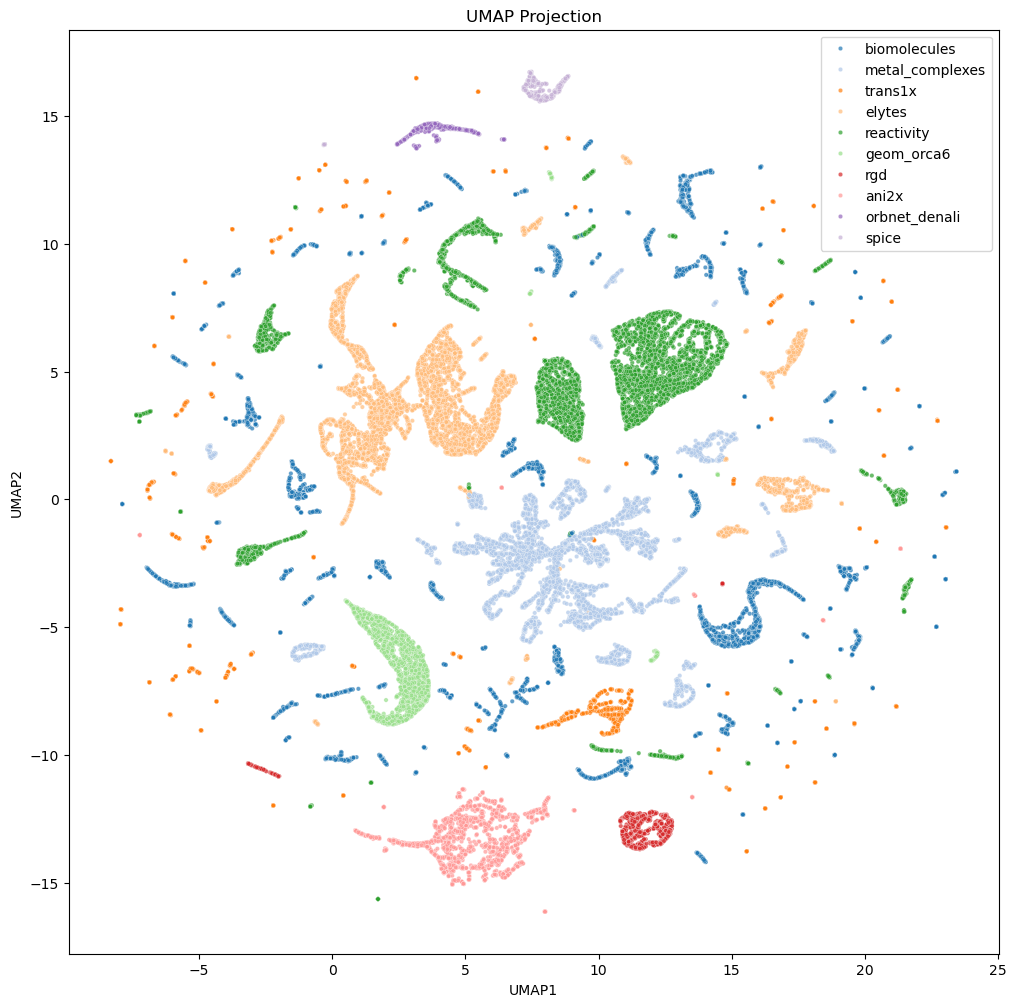

In [45]:
# do not include all in UMAP d/t constraints w/ computational power; plot UMAP with sample only 
num_samples = 50000 #50k samples 
num_neighbors = 30

x_umap = x_scaled.sample(n=num_samples, random_state=42) # set random state for reproducability 

labels = new_df.loc[x_umap.index, 'data_id'].reset_index(drop=True) # get only rows where idx's are matched 
newXY = umap.UMAP(random_state=42).fit_transform(x_umap) # new UMAP obj
umap_df = pd.DataFrame({'UMAP1': newXY[:, 0], 'UMAP2': newXY[:, 1], 'data_id': labels}) # convert back to df for plotting and coloring 

# plot 
fig = plt.figure(figsize=(12,12))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='data_id', palette='tab20', alpha=0.7, s=10) # color by molecule type 

plt.title('UMAP Projection')
plt.legend(fontsize=10)
plt.show()